In [3]:
import numpy as np

In [153]:
class KMeans:
    
    def __init__(
        self,
        n_clusters=3, 
        init='random',  # 'kmeans++'
        tol=1e-3,
        max_iter=300,
        distance='euclidean',
        given_centroids = None
    ):  # 'manhattan'
        
        self.n_clusters = n_clusters
        self.init = init
        self.tol = tol
        self.max_iter = max_iter
        self.distance = distance
        
        self.centroids = None
        self.labels = None
        
        self.inertia_history = []
        self.centroid_shift_history = []
        self.given_centroids = given_centroids
        
    # Вычисление расстояний
    def _compute_distance(self, X, centroids):

        if self.distance == 'euclidean':
            return np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        elif self.distance == 'manhattan':
            return np.sum(np.abs(X[:, np.newaxis] - centroids), axis=2)
        else:
            raise ValueError('Invalid distance name')
    
    # Инициализация
    def _init_random(self, X):
        
        indices = np.random.choice(len(X), self.n_clusters, replace=False)
        return X[indices]
    
    def _init_given(self):
        
        return self.given_centroids

    
    def _initialize_centroids(self, X):
        if self.init == 'random':
            return self._init_random(X)
        elif self.init == 'given':
            return self._init_given()
        else: 
            raise ValueError('Invalid initialization')
    
    # Шаги алгоритма
    def _assign_clusters(self, X):
        distances = self._compute_distance(X, self.centroids)
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                new_centroids[k] = self.centroids[k]
        
        return new_centroids
    
    def _compute_inertia(self, X, labels):
        distances = self._compute_distance(X, self.centroids)
        inertia = 0
        for i in range(len(X)):
            inertia += distances[i, labels[i]] ** 2
        return inertia
    
    def fit(self, X):
        X = np.asarray(X)
        

        self.centroids = self._initialize_centroids(X)
        
        for i in range(self.max_iter):

            labels = self._assign_clusters(X)
            

            new_centroids = self._update_centroids(X, labels)
            

            shift = np.linalg.norm(self.centroids - new_centroids)
            self.centroid_shift_history.append(shift)
            

            self.centroids = new_centroids
            

            inertia = self._compute_inertia(X, labels)
            self.inertia_history.append(inertia)
            
            print(f"Iter {i}, Inertia = {inertia:.3f}, Shift = {shift:.3f}")
            
            if shift < self.tol:
                print('Converged')
                break
        

        self.labels = self._assign_clusters(X)
        return self
    
    def predict(self, X):
        X = np.asarray(X)
        distances = self._compute_distance(X, self.centroids)
        return np.argmin(distances, axis=1)
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels


In [135]:
np.random.seed(42)
X_simple = np.vstack([
    np.random.normal(0, 0.5, (50, 2)),
    np.random.normal(2, 0.5, (50, 2)),
    np.random.normal(6, 2, (50, 2))
])

In [143]:
l = len(X_simple)
# X_simple[np.random.choice(l)]

In [136]:
import matplotlib.pyplot as plt

In [154]:
model1 = KMeans()
model1.fit(X_simple[np.random.choice(l, 40, replace = False)])

Iter 0, Inertia = 176.835, Shift = 1.863
Iter 1, Inertia = 133.022, Shift = 1.605
Iter 2, Inertia = 130.875, Shift = 0.186
Iter 3, Inertia = 130.875, Shift = 0.000
Converged


In [155]:
model1.centroids

array([[-0.04940551,  0.12992984],
       [ 6.49937047,  5.99586857],
       [ 1.92309467,  2.33345833]])

In [157]:
model = KMeans(init = 'given',
                given_centroids = model1.centroids)
model.fit(X_simple)

Iter 0, Inertia = 448.068, Shift = 0.247
Iter 1, Inertia = 448.068, Shift = 0.000
Converged


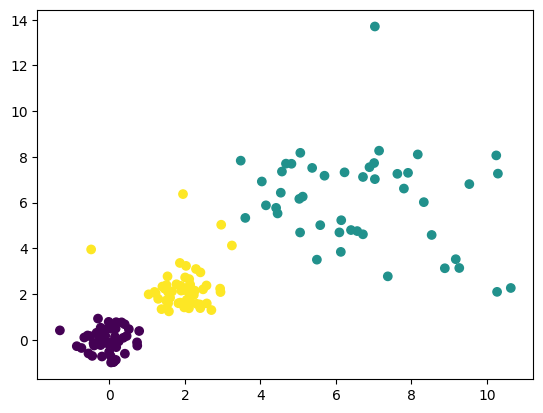

In [158]:
plt.scatter(X_simple[:, 0], X_simple[:, 1], c=model.labels)

Iter 0, Inertia = 523.187, Shift = 2.941
Iter 1, Inertia = 523.103, Shift = 0.023
Iter 2, Inertia = 523.089, Shift = 0.023
Iter 3, Inertia = 523.007, Shift = 0.051
Iter 4, Inertia = 522.897, Shift = 0.036
Iter 5, Inertia = 522.838, Shift = 0.035
Iter 6, Inertia = 522.689, Shift = 0.057
Iter 7, Inertia = 522.404, Shift = 0.093
Iter 8, Inertia = 522.015, Shift = 0.094
Iter 9, Inertia = 521.656, Shift = 0.107
Iter 10, Inertia = 521.608, Shift = 0.025
Iter 11, Inertia = 521.595, Shift = 0.022
Iter 12, Inertia = 521.595, Shift = 0.000
Converged


array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [24]:
x = np.array([[1,2],[2,3],[2,4], [5,4]])
y = np.array([[2,3], [1,1]])




In [46]:
np.asarray([[2,3], [3,4]])

array([[2, 3],
       [3, 4]])

In [49]:
x

array([[1, 2],
       [2, 3],
       [2, 4],
       [5, 4]])

In [52]:
def _init_random(X):
        
        indices = np.random.choice(len(X), 2, replace = False)
        
        return X[indices]

In [57]:
_init_random(x)

array([[2, 3],
       [2, 4]])

In [ ]:
# np. broadcast (скинуть материал)

In [35]:
y

array([[2, 3],
       [1, 1]])

array([1, 0, 0, 0])

In [44]:
np.linalg.norm(x[:, None] - y, axis = 2)

array([[1.41421356, 1.        ],
       [0.        , 2.23606798],
       [1.        , 3.16227766],
       [3.16227766, 5.        ]])

1.4142135623730951

8

In [22]:
np.linalg.norm(x)

2.23606797749979

# SKlearn

In [59]:
import numpy as np

from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

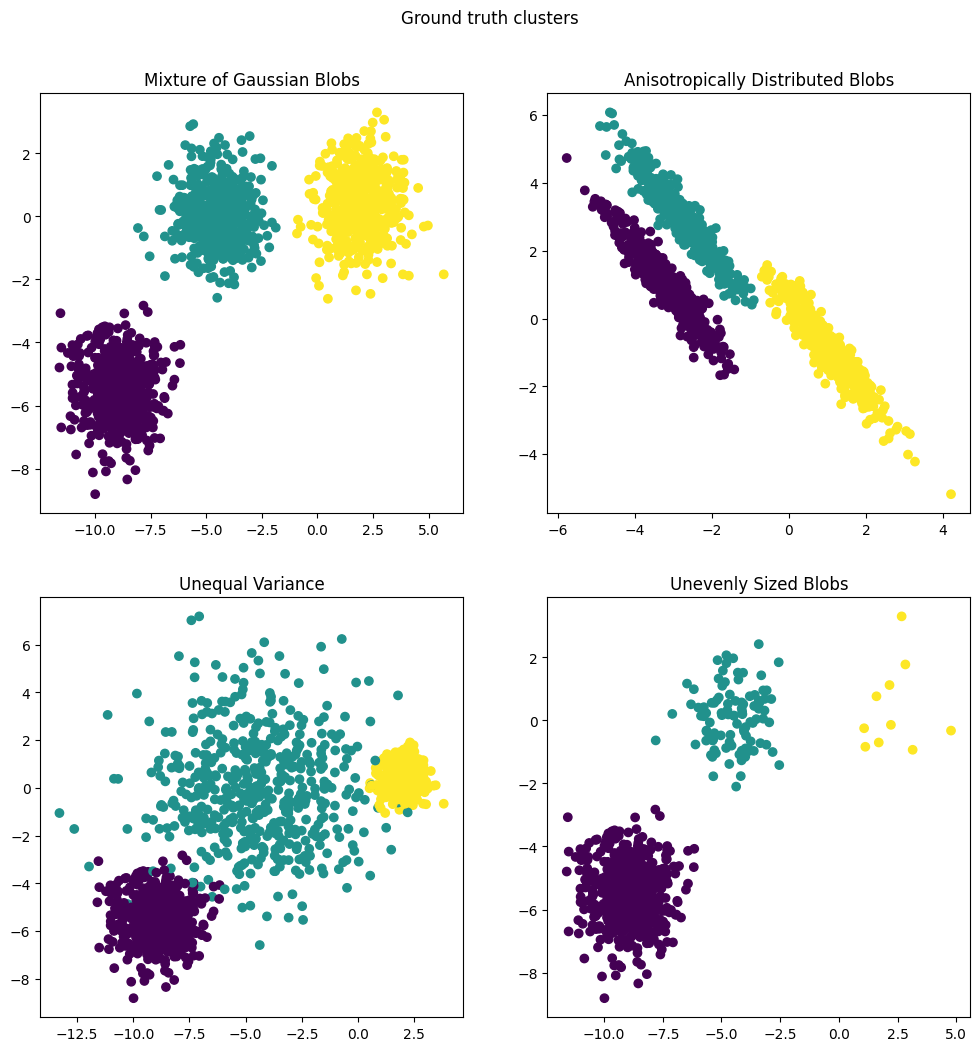

In [60]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

In [63]:
model = KMeans()

In [65]:
X

array([[-5.19811282e+00,  6.41869316e-01],
       [-5.75229538e+00,  4.18627111e-01],
       [-1.08448984e+01, -7.55352273e+00],
       ...,
       [ 1.36105255e+00, -9.07491863e-01],
       [-3.54141108e-01,  7.12241630e-01],
       [ 1.88577252e+00,  1.41185693e-03]])

In [64]:
model.fit_predict(X)

ValueError: operands could not be broadcast together with shapes (4,1,2) (1500,) 